# Behaviour PLS for ERP data

Here we use a single participant from the "kiloword dataset" ([Dufau et al., 2015](https://doi.org/10.1177/0956797615603934)) to demonstrate how behaviour PLS can be used to measure multivariate associations between ERP data and experimental covariates (in this case, various features of words presented to participants). It is valuable to compare this to the [MNE tutorial analyzing the same data using linear regression](https://mne.tools/stable/auto_examples/stats/sensor_regression.html).

## Loading and inspecting the data

The kiloword dataset ships with MNE and can be loaded as follows:

In [1]:
import mne
from mne.datasets import kiloword

# Load the data
path = kiloword.data_path() / "kword_metadata-epo.fif"
epochs = mne.read_epochs(path)

Reading C:\Users\isaac\mne_data\MNE-kiloword-data\kword_metadata-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -100.00 ...     920.00 ms
        0 CTF compensation matrices available
Adding metadata with 8 columns
960 matching events found
No baseline correction applied
0 projection items activated


The `epochs` variable contains ERP data for a single participant along with metadata with various features of the words presented per trial:

In [2]:
epochs.metadata

,WORD,Concreteness,WordFrequency,OrthographicDistance,NumberOfLetters,BigramFrequency,ConsonantVowelProportion,VisualComplexity
0,film,5.450000,3.189490,1.75,4.0,343.250,0.750,55.783710
1,cent,5.900000,3.700704,1.35,4.0,546.750,0.750,63.141553
2,shot,4.600000,2.858537,1.20,4.0,484.750,0.750,64.600033
3,cold,3.700000,3.454540,1.15,4.0,1095.250,0.750,63.657457
4,main,3.000000,3.539076,1.35,4.0,686.000,0.500,68.945661
...,...,...,...,...,...,...,...,...
955,drudgery,3.473684,1.556303,2.95,8.0,486.125,0.625,69.732357
956,reversal,3.700000,1.991226,2.65,8.0,859.000,0.625,60.545879
957,billiard,5.500000,1.672098,2.90,8.0,528.875,0.625,55.838597
958,adherent,3.450000,0.698970,2.55,8.0,615.625,0.625,68.088112


## Fitting and assessing the behaviour PLS model

We will examine associations between ERP data and several features of the words presented. To do so, we can fit a behaviour PLS model using `epochs.metadata` attribute as the design matrix and specifying the column names containing the covariates we want to examine.

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: xlabel='Time (s)', ylabel='Salience'>,
        <Axes: ylabel='Correlation with brain score'>], dtype=object))

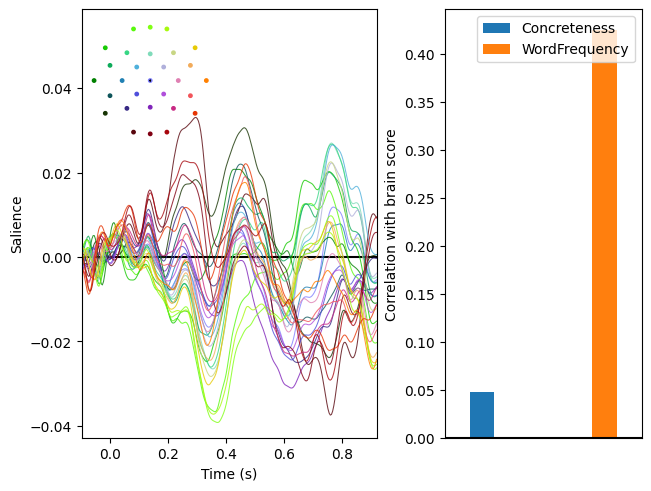

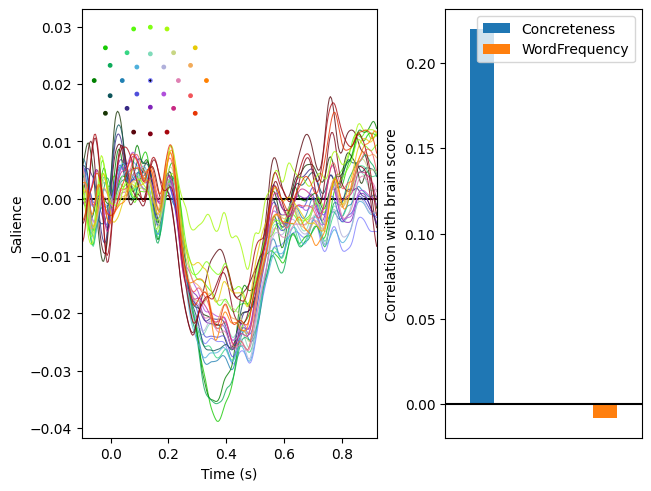

In [3]:
import mne_plsc

res = mne_plsc.fit_beh(epochs,
                       design=epochs.metadata,
                       covariates=['Concreteness', 'WordFrequency'],
                       random_state=123)
res.plot_lv(0, which='saliences')
res.plot_lv(1, which='saliences')

In the plots above, the left panels show the brain saliences for the first two latent variable pairs; i.e., the patterns maximally associated with the covariates. The right patterns display how strongly the expression of these patterns is associated with each covariates. As we can see, expression of the first pattern variable is most strongly related to word frequency and expression of the second is most strongly related to concreteness. Note the similarity of the second pattern of saliences to the pattern of regression weights identified by linear regression [here](https://mne.tools/stable/auto_examples/stats/sensor_regression.html).

We can assess the significance of these latent variable pairs via permutation testing. For speed, we will perform only 100 permutations, but for real data it would be advisable to do many more.

Permuting: 100%|██████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.38it/s]


   LV index  singular value  variance explained   p value
0         0        7.973536            0.614902  0.009901
1         1        6.310064            0.385098  0.009901


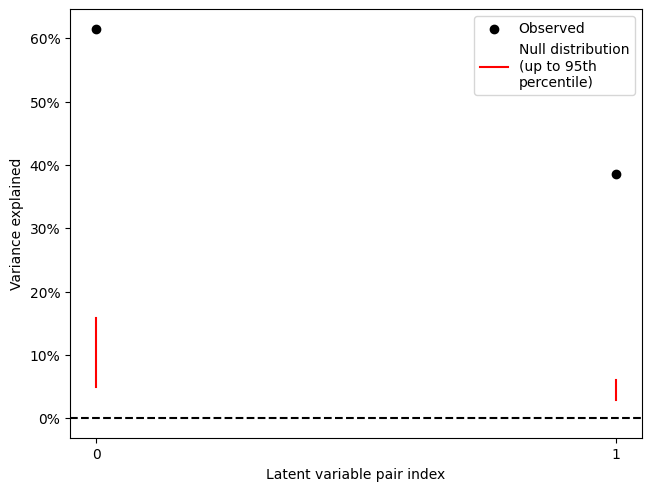

In [4]:
res.permute(100)
print(res.summary())
res.plot_scree()

As we can see, both latent variable pairs are significant (and in fact the extreme values of the null distribution of singular values are nowhere near the observed values).

## Cluster analysis

Having identified two patterns that are associated with the covariates, we next want to characterize them. For example, the second latent variable pair shows that concreteness is associated with a negative deflection between 0.2 and 0.6s. Where on the scalp does this negative deflection occur?

To answer this question, we will identify and plot any large clusters of strong saliences. First, we will use bootstrap resampling to estimate $z$ scores for the brain saliences.

In [11]:
res.bootstrap(100, return_boot_stat_dist=False)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:30<00:00,  3.25it/s]


Then, we will identify clusters of saliences whose $z$ scores are large (the default threshold is $|z| > 2$). Before cluster analysis, it is necessary to add an adjacency matrix to the data, indicating which channels and times can be part of the same cluster. For ERP analysis, it generally makes sense to treat all channels as adjacent in order to detect multi-channel patterns. This is the default behaviour of `.add_adjacency()` but can be changed with the `all_channels_adjacent` argument.

In [12]:
res.add_adjacency()
res.cluster()

Defaulting to all channels adjacent for ERP/ERF analysis
Clustering z-scores
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...
4 clusters
Computing clusters for lv_idx 1...
8 clusters


We will examine the second pattern of brain saliences (second latent variable pair, i.e., `lv_idx` 1), which is comparable to the example in the MNE documentation. We can examine the distribution of cluster sizes to see that most of the strong saliences are part of a single cluster:

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

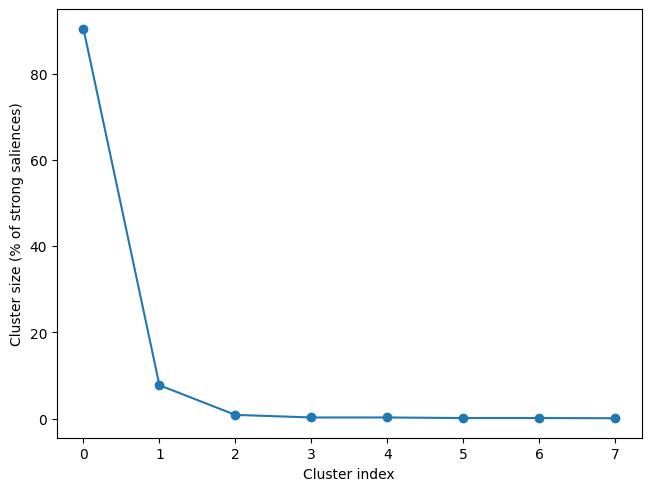

In [13]:
res.plot_cluster_sizes(lv_idx=1)

When we examine this cluster, we can see that it matches very closely the cluster of coefficients from the MNE example that are significant using FDR correction. Every channel is part of this cluster at some time point, but the strongest negative deflection occurs at left frontal electrodes, with the cluster peak (the strongest absolute $z$ score) at F7. To get a more spatially constrained cluster, we could repeat the clustering step with a higher threshold (e.g., `threshold=3` or higher).

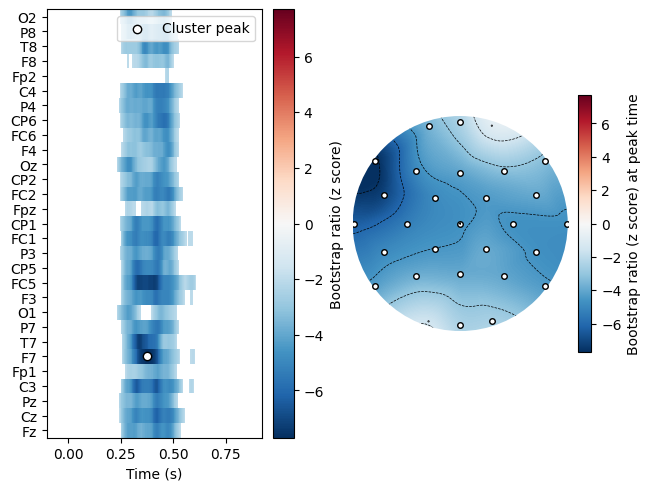

In [8]:
res.plot_cluster(lv_idx=1, cluster_idx=0, plot_type='raster')

It may appear that the plot includes disconnected "islands" of data that are not part of the cluster for FC1, F7, and C3. This is due to an inherent limitation of displaying channel locations along the linear y axis: there is no way to represent that these "islands" are in fact connected to the cluster via channels that are not contiguous along the y axis, but are in fact adjacent in the physical channel layout.